# 空间变异分析（Meuse 案例）

本文档按统一的分析逻辑组织，将理论、公式、代码与图件放在同一处连续展开：

1. 问题与建模对象（为什么不是 i.i.d.）  
2. 平稳性与可估计性（为什么能从一次空间实现估计结构）  
3. 协方差与半变异函数（数学关系与图像含义）  
4. 数据、变换与探索性检验（Meuse）  
5. 经验半变异（Matheron 分箱估计）  
6. 理论模型（球状/指数/高斯）与拟合  
7. 块金、基台、尺度参数解读  
8. 与克里金的关系与延伸方向

---

## 阅读目标

- 理解区域化变量、二阶平稳、内蕴假设的作用与区别。  
- 掌握经验半变异估计式及分箱参数的偏差-方差权衡。  
- 能从拟合曲线读出块金、部分基台、总基台与有效相关距离。  
- 理解“变异函数估计质量”如何影响克里金权重与预测不确定性。

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import font_manager

import geopandas as gpd
import gstools as gs

plt.style.use("seaborn-v0_8-whitegrid")


def configure_matplotlib_chinese() -> None:
    candidates = [
        "PingFang SC",
        "PingFang HK",
        "Hiragino Sans GB",
        "Songti SC",
        "STHeiti",
        "Heiti TC",
        "Arial Unicode MS",
        "Microsoft YaHei",
        "SimHei",
        "Noto Sans CJK SC",
    ]
    installed = {f.name for f in font_manager.fontManager.ttflist}
    for name in candidates:
        if name in installed:
            mpl.rcParams["font.family"] = "sans-serif"
            mpl.rcParams["font.sans-serif"] = [name, "DejaVu Sans", "Arial", "Helvetica"]
            mpl.rcParams["axes.unicode_minus"] = False
            return
    mpl.rcParams["font.sans-serif"] = [*candidates, *mpl.rcParams["font.sans-serif"]]
    mpl.rcParams["axes.unicode_minus"] = False


configure_matplotlib_chinese()


def repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in (cwd, *cwd.parents):
        if (p / "requirements.txt").is_file() and (p / "data").is_dir():
            return p
    return cwd


ROOT = repo_root()
DATA = ROOT / "data" / "processed" / "meuse.csv"
OUT = ROOT / "outputs"
OUT.mkdir(parents=True, exist_ok=True)

## 1) 为什么要做空间变异分析

设观测为 $Z(\mathbf{x}_1),\ldots,Z(\mathbf{x}_n)$。若按 i.i.d. 假设处理，默认

$$
\mathrm{Cov}(Z(\mathbf{x}_i), Z(\mathbf{x}_j)) = 0 \quad (i\neq j).
$$

但地理变量往往具有“近邻更相似”：

$$
\lVert \mathbf{x}_i-\mathbf{x}_j \rVert \uparrow \Rightarrow
\mathrm{Corr}(Z(\mathbf{x}_i),Z(\mathbf{x}_j)) \downarrow.
$$

因此关键问题不是“单点分布是什么”，而是“**点对相似性随距离如何衰减**”。  
这个衰减可由协方差函数 $C(\mathbf{h})$ 或半变异函数 $\gamma(\mathbf{h})$ 表达。

## 2) 随机函数、平稳性与可估计性

把区域化变量写为随机函数 $\{Z(\mathbf{x}):\mathbf{x}\in D\}$ 的一次实现。  
为了从“单个空间实现”估计总体结构，需要约束条件：

### 2.1 二阶平稳

$$
\mathbb{E}[Z(\mathbf{x})]=m,\qquad
\mathrm{Cov}(Z(\mathbf{x}),Z(\mathbf{x}+\mathbf{h}))=C(\mathbf{h}).
$$

含义：均值不随位置变；协方差只随滞后向量 $\mathbf{h}$ 变。

### 2.2 内蕴假设（更弱）

$$
\mathbb{E}[Z(\mathbf{x}+\mathbf{h})-Z(\mathbf{x})]=0,\qquad
\mathrm{Var}(Z(\mathbf{x}+\mathbf{h})-Z(\mathbf{x}))=2\gamma(\mathbf{h}).
$$

含义：不一定要求过程方差有限，但要求“增量方差”只依赖滞后。  
实践里若存在明显趋势（漂移），要先去趋势或使用泛克里金框架。

## 3) 协方差与半变异函数

协方差函数：

$$
C(\mathbf{h})=\mathbb{E}[(Z(\mathbf{x})-m)(Z(\mathbf{x}+\mathbf{h})-m)].
$$

半变异函数：

$$
\gamma(\mathbf{h})=\frac12\,\mathbb{E}\left[(Z(\mathbf{x}+\mathbf{h})-Z(\mathbf{x}))^2\right].
$$

在二阶平稳且方差有限时，有经典关系：

$$
\gamma(\mathbf{h})=C(\mathbf{0})-C(\mathbf{h}).
$$

这条式子给出直觉：$h$ 越大，协方差通常越小，半变异通常越大。  
下面先看 Meuse 数据与变换，再回到“曲线形状”的教学示意图。

## 4) 数据与变量变换

本例变量为土壤锌浓度 `zinc`（ppm）。考虑到重金属浓度常右偏，先做

$$
Y(\mathbf{x})=\log Z(\mathbf{x}),
$$

用 `log_zinc` 作为后续半变异分析对象。  
理由：对数后通常更接近对称，二阶结构更稳定。

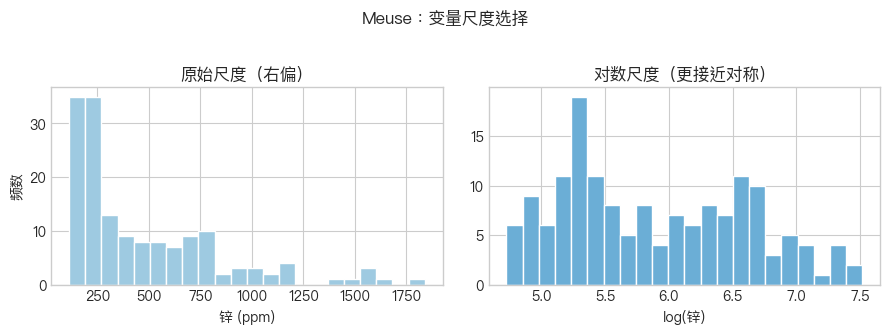

,x,y,cadmium,copper,lead,zinc,elev,dist,om,ffreq,soil,lime,landuse,dist.m,log_zinc,geometry
0,181072,333611,11.7,85,299,1022,7.909,0.001358,13.6,1,1,1,Ah,50,6.929517,POINT (181072 333611)
1,181025,333558,8.6,81,277,1141,6.983,0.012224,14.0,1,1,1,Ah,30,7.039660,POINT (181025 333558)
2,181165,333537,6.5,68,199,640,7.800,0.103029,13.0,1,1,1,Ah,150,6.461468,POINT (181165 333537)
3,181298,333484,2.6,81,116,257,7.655,0.190094,8.0,1,2,0,Ga,270,5.549076,POINT (181298 333484)
4,181307,333330,2.8,48,117,269,7.480,0.277090,8.7,1,2,0,Ah,380,5.594711,POINT (181307 333330)


In [2]:
df = pd.read_csv(DATA)
df["log_zinc"] = np.log(df["zinc"])
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["x"], df["y"]),
    crs="EPSG:28992",
)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
axes[0].hist(df["zinc"], bins=22, color="#9ecae1", edgecolor="white")
axes[0].set_xlabel("锌 (ppm)")
axes[0].set_ylabel("频数")
axes[0].set_title("原始尺度（右偏）")
axes[1].hist(df["log_zinc"], bins=22, color="#6baed6", edgecolor="white")
axes[1].set_xlabel("log(锌)")
axes[1].set_title("对数尺度（更接近对称）")
fig.suptitle("Meuse：变量尺度选择", y=1.03)
fig.tight_layout()
fig.savefig(OUT / "meuse_zinc_log_hist.png", dpi=150)
plt.show()

gdf.head()

## 5) 探索性空间图：趋势检查

估计 $\hat\gamma(h)$ 前，应检查是否存在显著趋势或分区。  
如果均值随位置系统变化，则“只依赖滞后”的平稳假设可能被破坏。

这里先画样点图（颜色 = `log_zinc`）做初检。

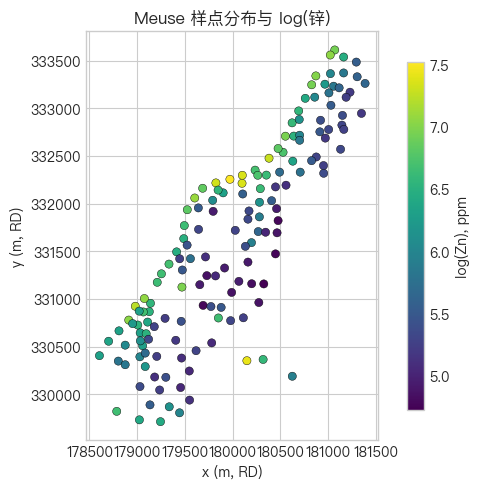

In [3]:
fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(
    gdf["x"],
    gdf["y"],
    c=gdf["log_zinc"],
    cmap="viridis",
    s=35,
    edgecolor="k",
    linewidths=0.3,
)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("x (m, RD)")
ax.set_ylabel("y (m, RD)")
cb = plt.colorbar(sc, ax=ax, shrink=0.85)
cb.set_label("log(Zn), ppm")
ax.set_title("Meuse 样点分布与 log(锌)")
fig.tight_layout()
fig.savefig(OUT / "meuse_logzn_points.png", dpi=150)
plt.show()

## 6) 曲线形状与模型示意

“块金、基台、变程”三个术语可先通过示意图建立直觉，再进入数据拟合。

球状模型（含块金）的常见写法：

$$
\gamma(h)=
\begin{cases}
C_0 + C_1\left[1.5\frac{h}{a}-0.5\left(\frac{h}{a}\right)^3\right], & 0<h\le a,\\
C_0 + C_1, & h>a.
\end{cases}
$$

- $C_0$：块金（nugget）  
- $C_1$：部分基台（partial sill）  
- $C_0+C_1$：总基台（sill）  
- $a$：球状模型的变程参数

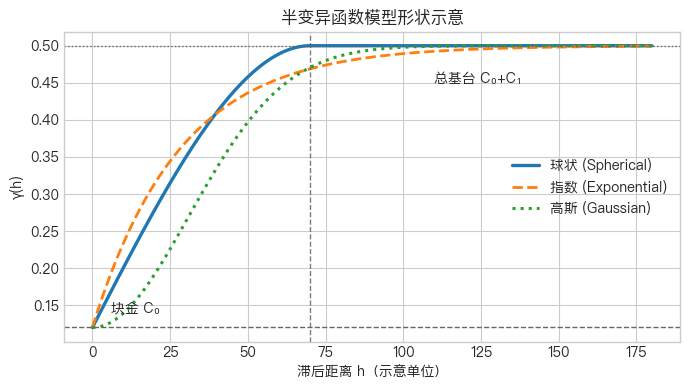

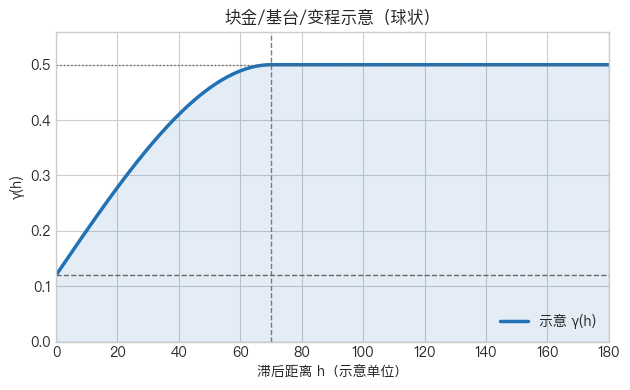

In [4]:
def spherical_gamma(h, nugget, partial_sill, rng):
    h = np.asarray(h, dtype=float)
    out = np.empty_like(h)
    m = h <= rng
    out[m] = nugget + partial_sill * (1.5 * h[m] / rng - 0.5 * (h[m] / rng) ** 3)
    out[~m] = nugget + partial_sill
    return out


def exponential_gamma(h, nugget, partial_sill, scale):
    h = np.asarray(h, dtype=float)
    return nugget + partial_sill * (1.0 - np.exp(-h / scale))


def gaussian_gamma(h, nugget, partial_sill, scale):
    h = np.asarray(h, dtype=float)
    return nugget + partial_sill * (1.0 - np.exp(-(h / scale) ** 2))


h = np.linspace(0, 180, 300)
C0, C1, a = 0.12, 0.38, 70.0

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(h, spherical_gamma(h, C0, C1, a), lw=2.4, label="球状 (Spherical)")
ax.plot(h, exponential_gamma(h, C0, C1, a / 2.5), "--", lw=2, label="指数 (Exponential)")
ax.plot(h, gaussian_gamma(h, C0, C1, a / 1.6), ":", lw=2.2, label="高斯 (Gaussian)")
ax.axhline(C0, color="#666", ls="--", lw=1)
ax.axhline(C0 + C1, color="#666", ls=":", lw=1)
ax.axvline(a, color="#666", ls="--", lw=1, alpha=0.85)
ax.annotate("块金 C₀", xy=(6, C0 + 0.02), fontsize=10)
ax.annotate("总基台 C₀+C₁", xy=(110, C0 + C1 - 0.05), fontsize=10)
ax.annotate("球状变程 a", xy=(a + 2, 0.04), fontsize=10)
ax.set_xlabel("滞后距离 h（示意单位）")
ax.set_ylabel("γ(h)")
ax.set_title("半变异函数模型形状示意")
ax.legend()
fig.tight_layout()
fig.savefig(OUT / "variogram_model_shapes.png", dpi=150)
plt.show()

# 单独保留球状参数示意图，便于文档引用
fig2, ax2 = plt.subplots(figsize=(6.4, 4))
gsph = spherical_gamma(h, C0, C1, a)
ax2.plot(h, gsph, color="#2171b5", lw=2.5, label="示意 γ(h)")
ax2.axhline(C0, color="#666", ls="--", lw=1)
ax2.axhline(C0 + C1, color="#666", ls=":", lw=1)
ax2.axvline(a, color="#666", ls="--", lw=1, alpha=0.85)
ax2.fill_between(h, 0, gsph, alpha=0.12, color="#2171b5")
ax2.set_xlim(0, 180)
ax2.set_ylim(0, C0 + C1 + 0.06)
ax2.set_xlabel("滞后距离 h（示意单位）")
ax2.set_ylabel("γ(h)")
ax2.set_title("块金/基台/变程示意（球状）")
ax2.legend(loc="lower right")
fig2.tight_layout()
fig2.savefig(OUT / "semivariogram_concept.png", dpi=150)
plt.show()

## 7) 经验半变异：Matheron 估计

把点对按距离分箱后，第 $k$ 个滞后箱的估计量为：

$$
\hat{\gamma}(h_k)=\frac{1}{2N_k}\sum_{(i,j)\in\mathcal{B}_k}(Z_i-Z_j)^2.
$$

其中 $\mathcal{B}_k$ 为第 $k$ 箱内点对集合，$N_k$ 为点对数。  
`width`（箱宽）和 `max_lag`（最大滞后）决定“平滑程度 vs 估计噪声”的权衡。

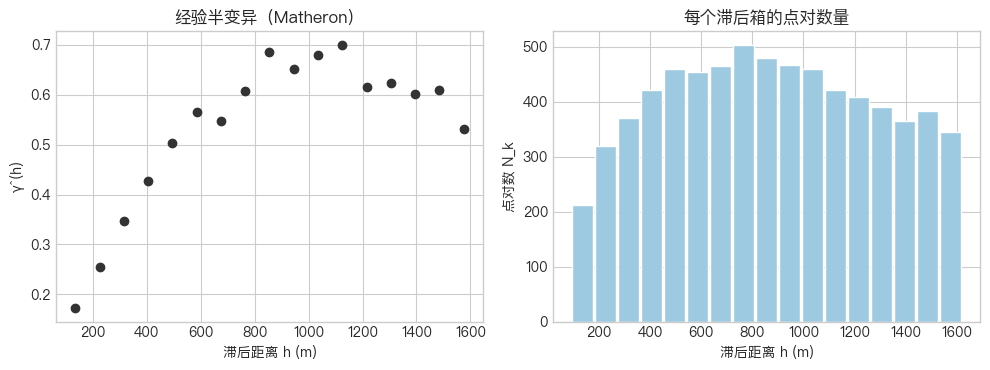

,lag_m,gamma_hat,pairs
0,135.0,0.17191,212
1,225.0,0.25549,320
2,315.0,0.34691,371
3,405.0,0.42631,422
4,495.0,0.50331,459
5,585.0,0.56500,455
6,675.0,0.54787,466
7,765.0,0.60767,503
8,855.0,0.68524,480
9,945.0,0.65161,468


In [5]:
pos = np.array([gdf["x"].to_numpy(), gdf["y"].to_numpy()])
field = gdf["log_zinc"].to_numpy()

max_lag = 1600.0
width = 90.0
bin_edges = np.arange(width, max_lag + width, width)

bin_center, emp_gamma, counts = gs.vario_estimate(
    pos,
    field,
    bin_edges,
    estimator="matheron",
    mesh_type="unstructured",
    return_counts=True,
)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].plot(bin_center, emp_gamma, "o", color="0.2")
axes[0].set_xlabel("滞后距离 h (m)")
axes[0].set_ylabel("γ̂(h)")
axes[0].set_title("经验半变异（Matheron）")

axes[1].bar(bin_center, counts, width=width * 0.9, color="#9ecae1", edgecolor="white")
axes[1].set_xlabel("滞后距离 h (m)")
axes[1].set_ylabel("点对数 N_k")
axes[1].set_title("每个滞后箱的点对数量")

fig.tight_layout()
fig.savefig(OUT / "empirical_variogram.png", dpi=150)
plt.show()

pd.DataFrame(
    {"lag_m": np.round(bin_center, 1), "gamma_hat": np.round(emp_gamma, 5), "pairs": counts}
).head(10)

## 8) 理论模型拟合与比较

在合法模型族（球状/指数/高斯）中拟合参数，比较经验点上的误差。  
这里用 RMS 作为拟合优度的比较指标：

$$
\mathrm{RMS}=\sqrt{\frac{1}{K}\sum_{k=1}^{K}\left[\gamma_\theta(h_k)-\hat\gamma(h_k)\right]^2 }.
$$

Spherical     nugget=0.0368  partial_sill=0.5940  len_scale=870.3 m
Exponential   nugget=0.0000  partial_sill=0.6550  len_scale=353.4 m
Gaussian      nugget=0.1265  partial_sill=0.5038  len_scale=373.6 m
RMS 对比: {'Spherical': 0.03805, 'Exponential': 0.05068, 'Gaussian': 0.03871}
最优模型: Spherical


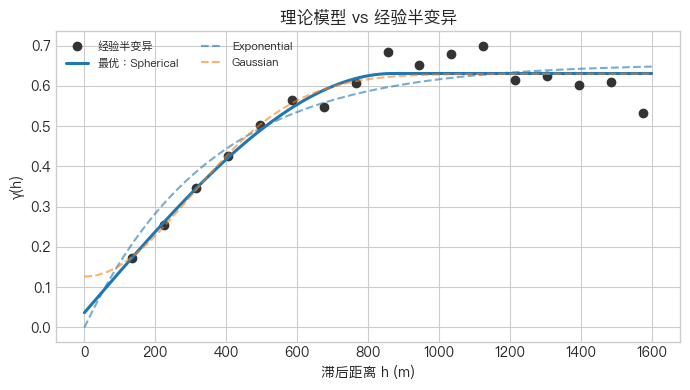

In [6]:
candidates = {
    "Spherical": gs.Spherical(dim=2),
    "Exponential": gs.Exponential(dim=2),
    "Gaussian": gs.Gaussian(dim=2),
}

fits = {}
for name, model in candidates.items():
    m = model
    m.fit_variogram(bin_center, emp_gamma, nugget=True)
    fits[name] = m
    print(
        f"{name:12s}  nugget={m.nugget:.4f}  partial_sill={m.var:.4f}  len_scale={m.len_scale:.1f} m"
    )

errs = {}
x = np.linspace(0, float(max_lag), 220)
for name, m in fits.items():
    errs[name] = float(np.sqrt(np.mean((m.variogram(bin_center) - emp_gamma) ** 2)))

best = min(errs, key=errs.get)
best_m = fits[best]
print("RMS 对比:", {k: round(v, 5) for k, v in errs.items()})
print("最优模型:", best)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(bin_center, emp_gamma, "o", color="0.2", label="经验半变异")
ax.plot(x, best_m.variogram(x), "-", color="C0", linewidth=2.2, label=f"最优：{best}")
for name, m in fits.items():
    if name == best:
        continue
    ax.plot(x, m.variogram(x), "--", alpha=0.6, label=name)
ax.set_xlabel("滞后距离 h (m)")
ax.set_ylabel("γ(h)")
ax.set_title("理论模型 vs 经验半变异")
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()
fig.savefig(OUT / "fitted_variogram_models.png", dpi=150)
plt.show()

## 9) 参数解读与克里金连接

给定最优模型后，读出：

- 块金：$C_0$  
- 部分基台：$C_1$  
- 总基台：$C_0+C_1$

不同模型中“尺度参数”与“实用相关距离”换算不同，常用近似为：

- Spherical：$r_{\text{eff}}\approx a$  
- Exponential：$r_{\text{eff}}\approx 3a$  
- Gaussian：$r_{\text{eff}}\approx \sqrt{3}a$

克里金中，权重由协方差结构决定；因此半变异模型不是“画图收尾”，而是预测器的核心输入。

In [7]:
nug = float(best_m.nugget)
ps = float(best_m.var)
sill = nug + ps
len_scale = float(best_m.len_scale)

if best == "Spherical":
    eff_range = len_scale
elif best == "Exponential":
    eff_range = 3 * len_scale
elif best == "Gaussian":
    eff_range = np.sqrt(3) * len_scale
else:
    eff_range = np.nan

summary = pd.DataFrame(
    {
        "模型": [best],
        "块金 nugget": [round(nug, 4)],
        "部分基台 partial_sill": [round(ps, 4)],
        "总基台 sill": [round(sill, 4)],
        "len_scale(m)": [round(len_scale, 1)],
        "经验有效距离(m)": [round(float(eff_range), 1)],
    }
)
summary

,模型,块金 nugget,部分基台 partial_sill,总基台 sill,len_scale(m),经验有效距离(m)
0,Spherical,0.0368,0.594,0.6308,870.3,870.3


## 10) 延伸与复现建议

1. 把 `width` 从 `90` 改为 `60` 和 `120`，比较经验曲线抖动与拟合结果变化。  
2. 只用较短 `max_lag`（如 1000 m）重新拟合，观察块金/基台是否稳定。  
3. 尝试去趋势（例如对 `x`,`y` 做线性回归取残差）后再估计半变异，比较差异。  
4. 若出现各向异性（沿河流方向相关更强），可扩展到方向变异函数与各向异性建模。

---

### 产出图件（`outputs/`）

| 文件 | 内容 |
|------|------|
| `meuse_zinc_log_hist.png` | 原始锌与 log(锌) 直方图 |
| `meuse_logzn_points.png` | 样点空间分布 |
| `variogram_model_shapes.png` | 球状/指数/高斯模型形状示意 |
| `semivariogram_concept.png` | 块金/基台/变程示意（球状） |
| `empirical_variogram.png` | 经验半变异 + 点对数 |
| `fitted_variogram_models.png` | 理论模型拟合对比 |